# lets implement basic cv

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from PIL import Image

In [52]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [53]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
trainset = torchvision.datasets.CIFAR10(
    root=r"C:\Users\Panshul\Desktop\panshul\download\CIFAR10(CV) DATASET\train",
    train=True,
    download=True,
    transform=transform
)
testset = torchvision.datasets.CIFAR10(
    root = r"C:\Users\Panshul\Desktop\panshul\download\CIFAR10(CV) DATASET\test",
    train = False,
    download = True,
    transform = transform,
)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size = 64, shuffle=False)

### defining CNN

In [54]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Conv layer 1: Input = 3x32x32 → Output = 16x32x32
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        # Conv layer 2: Input = 16x16x16 → Output = 32x16x16
        self.conv2 = nn.Conv2d(16, 32, 3, 1, 1)
        # Conv layer 3: Input = 32x8x8 → Output = 64x8x8
        self.conv3 = nn.Conv2d(32, 64, 3, 1, 1)

        # Max Pooling (reduces each spatial dimension by half)
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        # After 3 poolings: 32x32 → 16x16 → 8x8 → 4x4
        self.fc1 = nn.Linear(64 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)  # 10 classes for CIFAR-10

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # -> 16x16x16
        x = self.pool(F.relu(self.conv2(x)))  # -> 32x8x8
        x = self.pool(F.relu(self.conv3(x)))  # -> 64x4x4
        x = x.view(-1, 64 * 4 * 4)            # Flatten(converting 3d to 1d for dense layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)                      
        return x

model = CNNModel().to(device)

### loss fn and optimizer

In [56]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### training loop

In [57]:

for epoch in range(5):  # for 5 epochs
    running_loss = 0.0
    for images, labels in trainloader:
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/5] | Loss: {running_loss/len(trainloader):.4f}")

print("Training complete ✅")


Epoch [1/5] | Loss: 1.5263
Epoch [2/5] | Loss: 1.1276
Epoch [3/5] | Loss: 0.9295
Epoch [4/5] | Loss: 0.8067
Epoch [5/5] | Loss: 0.7057
Training complete ✅


### testing accuracy

In [59]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        # Move images and labels to device
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")


Accuracy: 70.81%


### lets try to visualize also

In [60]:
import matplotlib.pyplot as plt

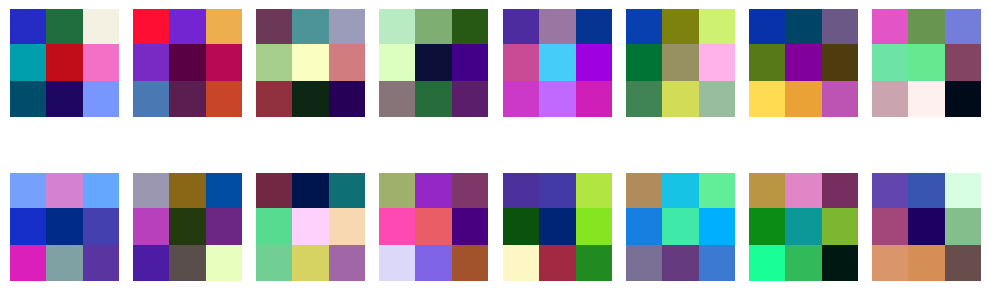

In [62]:
# Clone and move filters to CPU
filters = model.conv1.weight.data.clone().cpu()

# Normalize each filter individually (channel-wise)
for idx in range(filters.shape[0]):
    filt = filters[idx]
    min_val = filt.min()
    max_val = filt.max()
    filters[idx] = (filt - min_val) / (max_val - min_val + 1e-5)

num_filters = filters.shape[0]
ncols = 8
nrows = (num_filters + ncols - 1) // ncols

fig, axarr = plt.subplots(nrows, ncols, figsize=(10, nrows * 2))
for idx in range(num_filters):
    # [C, H, W] to [H, W, C], move tensor to CPU and numpy
    f_img = filters[idx].permute(1, 2, 0).cpu().numpy()
    axarr[idx // ncols, idx % ncols].imshow(f_img)
    axarr[idx // ncols, idx % ncols].axis('off')

# Turn off unused axes
for idx in range(num_filters, ncols * nrows):
    axarr[idx // ncols, idx % ncols].axis('off')

plt.tight_layout()
plt.show()

IndexError: index 16 is out of bounds for dimension 0 with size 16

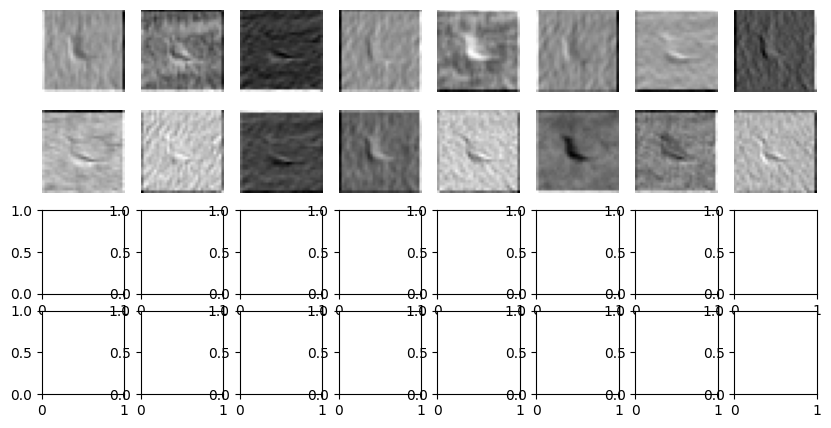

In [64]:
img = Image.open("100.png")

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

img_tensor = transform(img).unsqueeze(0).to(device)

activations = {}
def hook_fn(module, input, output):
    activations['conv1'] = output

hook = model.conv1.register_forward_hook(hook_fn)

with torch.no_grad():
    _ = model(img_tensor)

act = activations['conv1'].squeeze().detach().cpu()

fig, axarr = plt.subplots(4, 8, figsize=(10, 5))
for idx in range(32):
    axarr[idx//8, idx%8].imshow(act[idx], cmap='gray')
    axarr[idx//8, idx%8].axis('off')

plt.tight_layout()
plt.show()


hook.remove()